In [1]:
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpu3ruj7ee".


In [2]:
# Скрипт для запуска CUDA программы на T4 в Google Colab

# 1. Проверка доступного GPU
!nvidia-smi
print("\n" + "="*60)

# 2. Установка правильной версии CUDA Toolkit для T4
!apt-get update
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64/cuda-keyring_1.0-1_all.deb
!dpkg -i cuda-keyring_1.0-1_all.deb
!apt-get update
!apt-get -y install cuda-toolkit-11-8

# 3. Настройка переменных окружения
import os
os.environ['PATH'] = '/usr/local/cuda-11.8/bin:' + os.environ['PATH']
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-11.8/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# 4. Проверка установки
!nvcc --version
print("\n" + "="*60)

Thu Jun  4 19:54:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

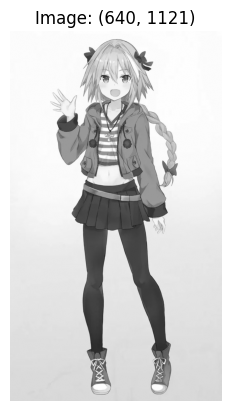

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('sample_data/girl.jpg').convert('L')
# тест
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"Image: {img.size}")
plt.show()

In [35]:
import os
import numpy as np
from PIL import Image
import urllib.request

# Скачиваем stb_image хедеры (для работы с BMP в C)
for f in ['stb_image.h', 'stb_image_write.h']:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/nothings/stb/master/{f}', f)
print("✅ stb headers ready")

# Grayscale
img = Image.open('sample_data/girl.jpg').convert('L')
arr = np.array(img)
h, w = arr.shape

noisy = arr.copy()
prob = 0.15
mask = np.random.rand(h, w)
noisy[mask < prob/2] = 0
noisy[mask > 1 - prob/2] = 255

Image.fromarray(noisy).save('sample_data/girl_noised.bmp')
print(f"Создан girl_nosed.bmp ({w}x{h}) с шумом")

"""
Генерация BMP для бенчмарка. Случайное содержимое не повлияет на работоспособность.
Фиксированные размеры позволят провести хорошие эксперименты
"""
sizes = [500, 1000, 2000, 3000, 5000, 8000, 10000]
os.makedirs('sample_data/bench', exist_ok=True)
for s in sizes:
    arr = np.random.randint(0, 256, (s, s), dtype=np.uint8)
    Image.fromarray(arr).save(f'sample_data/bench/{s}x{s}.bmp')
print("Сгенерированы sample_data/bench/*.bmp для тестов производительности")

✅ stb headers ready
Создан girl_nosed.bmp (640x1121) с шумом
Сгенерированы sample_data/bench/*.bmp для тестов производительности


In [36]:
%%writefile median_filter.cu
#include <iostream>
#include <chrono>
#include <cuda_runtime.h>

#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

#define CUDA_CHECK(call) \
    do { cudaError_t err = call; if (err != cudaSuccess) { \
        std::cerr << "CUDA error: " << cudaGetErrorString(err) << std::endl; exit(1); }} while(0)

// --- CPU Baseline ---
void medianFilterCPU(unsigned char* in, unsigned char* out, int w, int h) {
    for (int y = 0; y < h; y++) {
        for (int x = 0; x < w; x++) {
            unsigned char vals[9]; int idx = 0;
            for (int dy = -1; dy <= 1; dy++) {
                for (int dx = -1; dx <= 1; dx++) {
                    int nx = x + dx, ny = y + dy;
                    // Clamp вручную
                    nx = (nx < 0) ? 0 : (nx >= w ? w - 1 : nx);
                    ny = (ny < 0) ? 0 : (ny >= h ? h - 1 : ny);
                    vals[idx++] = in[ny * w + nx];
                }
            }
            // Bubble sort для 9 элементов
            for (int i = 0; i < 9; i++)
                for (int j = 0; j < 8 - i; j++)
                    if (vals[j] > vals[j+1]) {
                        unsigned char t = vals[j]; vals[j] = vals[j+1]; vals[j+1] = t;
                    }
            out[y * w + x] = vals[4];
        }
    }
}

// --- GPU Kernel ---
__global__ void medianFilterKernel(unsigned char* out, int w, int h, cudaTextureObject_t tex) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    unsigned char vals[9]; int idx = 0;
    for (int dy = -1; dy <= 1; dy++) {
        for (int dx = -1; dx <= 1; dx++) {
            // Текстурная выборка с Clamp (настроено при создании tex)
            vals[idx++] = tex2D<unsigned char>(tex, x + dx + 0.5f, y + dy + 0.5f);
        }
    }
    for (int i = 0; i < 9; i++)
        for (int j = 0; j < 8 - i; j++)
            if (vals[j] > vals[j+1]) {
                unsigned char t = vals[j]; vals[j] = vals[j+1]; vals[j+1] = t;
            }
    out[y * w + x] = vals[4];
}

int main(int argc, char* argv[]) {
    int w, h, ch;
    unsigned char* h_in = stbi_load(argv[1], &w, &h, &ch, 1); // 1 канал = Grayscale
    if (!h_in) { std::cerr << "Failed to load image" << std::endl; return 1; }

    unsigned char* h_out_cpu = new unsigned char[w * h];
    unsigned char* h_out_gpu = new unsigned char[w * h];
    unsigned char* d_out;
    CUDA_CHECK(cudaMalloc(&d_out, w * h));

    // CPU Run
    auto t0 = std::chrono::high_resolution_clock::now();
    medianFilterCPU(h_in, h_out_cpu, w, h);
    auto t1 = std::chrono::high_resolution_clock::now();
    double cpu_ms = std::chrono::duration<double, std::milli>(t1 - t0).count();

    // GPU Setup (Texture Memory)
    unsigned char* d_in; size_t pitch;
    CUDA_CHECK(cudaMallocPitch(&d_in, &pitch, w, h));
    CUDA_CHECK(cudaMemcpy2D(d_in, pitch, h_in, w, w, h, cudaMemcpyHostToDevice));

    cudaResourceDesc resDesc = {};
    resDesc.resType = cudaResourceTypePitch2D;
    resDesc.res.pitch2D.devPtr = d_in;
    resDesc.res.pitch2D.width = w; resDesc.res.pitch2D.height = h;
    resDesc.res.pitch2D.pitchInBytes = pitch;
    resDesc.res.pitch2D.desc = cudaCreateChannelDesc<unsigned char>();

    cudaTextureDesc texDesc = {};
    texDesc.addressMode[0] = cudaAddressModeClamp;
    texDesc.addressMode[1] = cudaAddressModeClamp;
    texDesc.filterMode = cudaFilterModePoint;
    texDesc.readMode = cudaReadModeElementType;
    texDesc.normalizedCoords = 0;

    cudaTextureObject_t tex = 0;
    CUDA_CHECK(cudaCreateTextureObject(&tex, &resDesc, &texDesc, NULL));

    // GPU Run
    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start)); CUDA_CHECK(cudaEventCreate(&stop));

    dim3 block(16, 16);
    dim3 grid((w + 15) / 16, (h + 15) / 16);

    CUDA_CHECK(cudaEventRecord(start));
    medianFilterKernel<<<grid, block>>>(d_out, w, h, tex);
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float gpu_ms = 0;
    CUDA_CHECK(cudaEventElapsedTime(&gpu_ms, start, stop));

    CUDA_CHECK(cudaMemcpy(h_out_gpu, d_out, w * h, cudaMemcpyDeviceToHost));

    // Сохранение результата (GPU)
    stbi_write_bmp(argv[2], w, h, 1, h_out_gpu);

    // Вывод времени для Python
    printf("%.3f,%.3f\n", cpu_ms, gpu_ms);

    // Очистка
    stbi_image_free(h_in);
    delete[] h_out_cpu; delete[] h_out_gpu;
    CUDA_CHECK(cudaFree(d_in)); CUDA_CHECK(cudaFree(d_out));
    CUDA_CHECK(cudaDestroyTextureObject(tex));
    CUDA_CHECK(cudaEventDestroy(start)); CUDA_CHECK(cudaEventDestroy(stop));
    return 0;
}

Overwriting median_filter.cu


Запуск бенчмарков...
500x500: CPU=41.62ms, GPU=0.21ms, Speedup=200.08x
1000x1000: CPU=157.93ms, GPU=0.23ms, Speedup=677.79x
2000x2000: CPU=639.02ms, GPU=0.44ms, Speedup=1449.02x
3000x3000: CPU=1607.61ms, GPU=1.27ms, Speedup=1264.83x
5000x5000: CPU=4155.00ms, GPU=2.69ms, Speedup=1545.76x
8000x8000: CPU=10781.64ms, GPU=6.61ms, Speedup=1630.37x
10000x10000: CPU=16468.53ms, GPU=10.13ms, Speedup=1625.56x


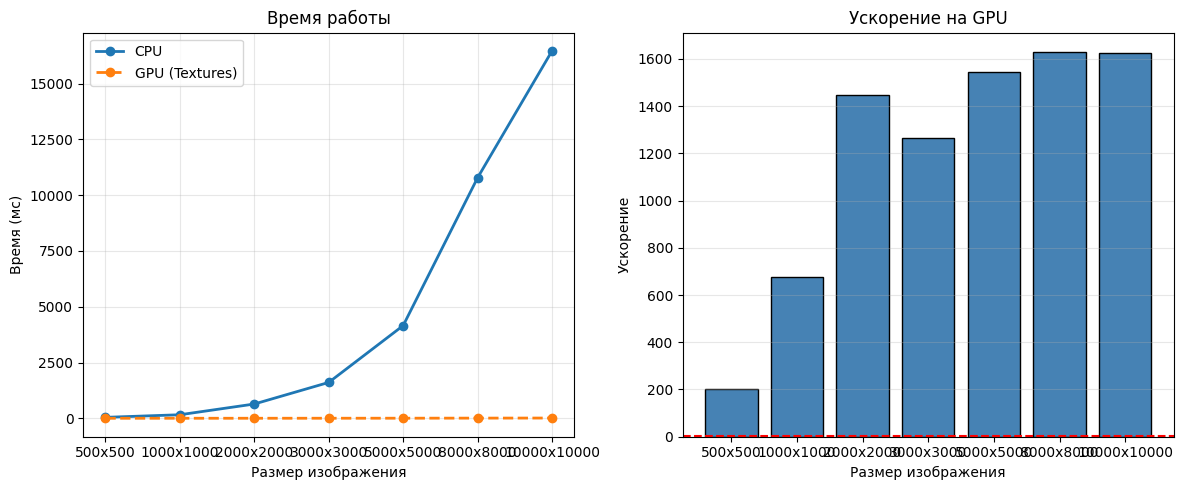

In [37]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

sizes = [500, 1000, 2000, 3000, 5000, 8000, 10000]
data = []

print("Запуск бенчмарков...")
for s in sizes:
    inp = f'sample_data/bench/{s}x{s}.bmp'
    out = f'sample_data/bench/out_{s}x{s}.bmp'

    res = subprocess.run(['./median_filter', inp, out], capture_output=True, text=True)
    if res.returncode == 0:
        cpu, gpu = map(float, res.stdout.strip().split(','))
        speedup = cpu / gpu if gpu > 0.001 else 0
        data.append({'Size': f'{s}x{s}', 'CPU_ms': cpu, 'GPU_ms': gpu, 'Speedup': speedup})
        print(f"{s}x{s}: CPU={cpu:.2f}ms, GPU={gpu:.2f}ms, Speedup={speedup:.2f}x")

df = pd.DataFrame(data)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df['Size'], df['CPU_ms'], 'o-', label='CPU', linewidth=2)
plt.plot(df['Size'], df['GPU_ms'], 'o--', label='GPU (Textures)', linewidth=2)
plt.xlabel('Размер изображения')
plt.ylabel('Время (мс)')
plt.title('Время работы')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(df['Size'], df['Speedup'], color='steelblue', edgecolor='black')
plt.axhline(1, color='red', linestyle='--')
plt.xlabel('Размер изображения')
plt.ylabel('Ускорение')
plt.title('Ускорение на GPU')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Запускаем на изображении из интернета
! ./median_filter sample_data/girl_noised.bmp sample_data/output.bmp

CompletedProcess(args=['./median_filter', 'sample_data/girl_noised.bmp', 'sample_data/output.bmp'], returncode=0)

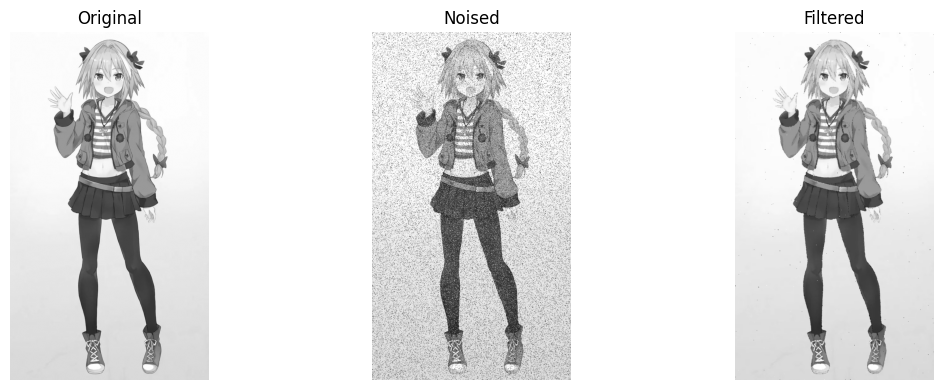

In [40]:
# Визуализация и сохранение изображения из интернета
orig = Image.open('sample_data/girl.jpg').convert('L')
noisy = Image.open('sample_data/girl_noised.bmp')
filtered = Image.open('sample_data/output.bmp')

plt.figure(figsize=(12, 4))
titles = ['Original', 'Noised', 'Filtered']
imgs = [orig, noisy, filtered]
for i, (img, title) in enumerate(zip(imgs, titles), 1):
    plt.subplot(1, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()